# Quantitative Portfolio Optimization & Risk Analysis

## 1. Project Goal

In this project, we apply quantitative finance techniques in order to construct and analyze a stock portfolio.

The goal is to investigate the relationship between risk and return using logarithmic returns, volatility, correlation matrices, covariance matrices, Monte Carlo simulation, and portfolio optimization techniques.

More specifically, having fixed the assets composing our portfolio, we aim to identify the optimal weights in order to achieve an efficient trade-off between expected return and risk, based on the principles of Modern Portfolio Theory.

## 2. Ipmorting Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.optimize import minimize

## 3. Data Collection

We collect historical stock data for companies from different market sectors:  technology, healthcare, financials, consumer staples, and energy. 

In this way, one can better examine the effects of diversification and correlation on portfolio risk and performance.

In addition to our portfolio stocks, we include the S&P 500 index as a benchmark representing the overall market. We shall compare the portfolio's performance with that of the index.

In [34]:
stocks = ['AAPL', 'MSFT', 'JNJ', 'JPM', 'KO', 'XOM']

benckmark = '^GSPC'

In [35]:
data = yf.download(stocks, start='2020-01-01', end='2025-01-01', auto_adjust=False)['Adj Close']

data.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Date,,,,,,
2020-01-02,72.333862,122.638222,118.430328,45.432716,151.829544,52.947041
2020-01-03,71.630630,121.218338,116.867477,45.184849,149.938980,52.521362
2020-01-06,72.201401,121.067123,116.774551,45.168316,150.326584,52.924625
2020-01-07,71.861839,121.806488,114.789299,44.821312,148.955963,52.491497
2020-01-08,73.017845,121.789680,115.684761,44.903942,151.328598,51.699894


In [36]:
benchmark_data = yf.download(benckmark, start='2020-01-01', end='2025-01-01', auto_adjust=False)['Adj Close']

benchmark_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049


**Remark:** Throughout this project we use adjusted closing prices, due to their providing a more accurate representation of asset values.

**Remark:** The selected time period (2020-2025) is particularly interesting, because it includes several events which significantly influenced market performance, such as COVID-19 and its consequences.

Moreover, the five-year time horizon provides a sufficient number of observations for our statistical analysis. 

# 4. Data Inspection & Cleaning

Before proceeding with the analysis, we inspect the structure and quality of our datasets.

In [37]:
data.shape

(1258, 6)

In [38]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   JNJ     1258 non-null   float64
 2   JPM     1258 non-null   float64
 3   KO      1258 non-null   float64
 4   MSFT    1258 non-null   float64
 5   XOM     1258 non-null   float64
dtypes: float64(6)
memory usage: 68.8 KB


In [39]:
data.isnull().sum()

Ticker
AAPL    0
JNJ     0
JPM     0
KO      0
MSFT    0
XOM     0
dtype: int64

In [40]:
data.describe()

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,151.377786,143.684102,135.491525,51.910028,285.724091,73.433010
std,41.851998,11.824775,37.831734,7.368286,81.058643,28.858525
min,54.163708,93.970840,66.763321,31.304205,128.358322,23.823559
25%,126.279118,138.840370,109.972448,46.773108,226.536346,46.591518
50%,149.968605,145.948975,132.128471,53.756041,273.605881,79.235249
75%,175.902016,151.726971,147.840569,56.735520,330.229881,99.136553
max,257.375580,165.628799,242.758438,69.427246,460.325592,118.348564


The descriptive statistics provide an initial overview of the price levels and variability of the selected assets over the examined period.

We now perform the same inspection process for the benchmark dataset.

In [41]:
benchmark_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^GSPC   1258 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB


In [42]:
benchmark_data.isnull().sum()

Ticker
^GSPC    0
dtype: int64

**Remark:** Both datasets contain no missing values.

# 5. Exploratory Price Analysis

In this section, we examine the evolution of both the portfolio asset prices and the benchmark index over time.

We begin with the portfolio assets.

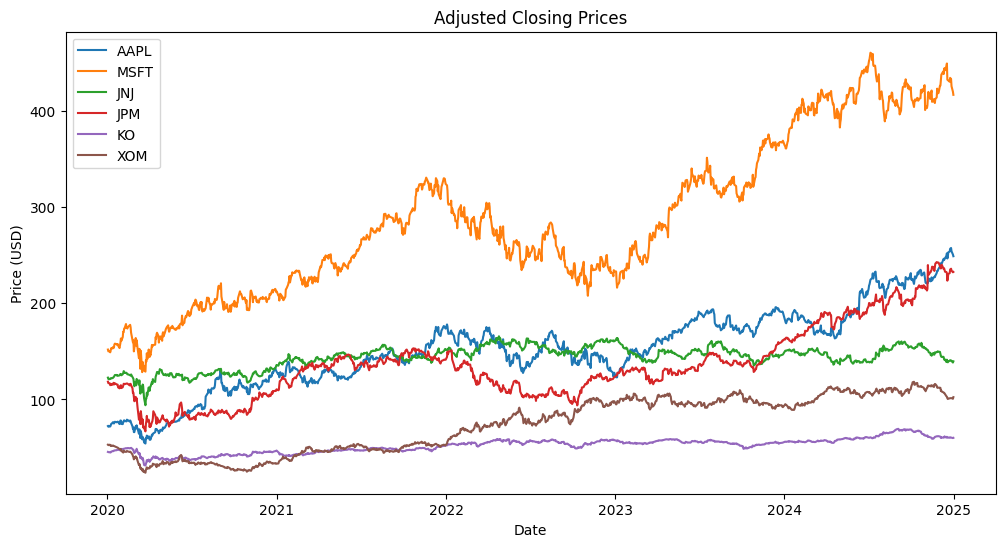

In [43]:
plt.figure(figsize=(12,6))

for stock in stocks:
    
    plt.plot(data[stock], label=stock)

plt.title('Adjusted Closing Prices')

plt.xlabel('Date')

plt.ylabel('Price (USD)')

plt.legend()

plt.show()

**Remark:** All assets exhibit an overall upward trend. However, noticeable differences in growth rate and volatility can still be observed.

Next, we examine the S&P 500 graph, which represents the overall market behavior.

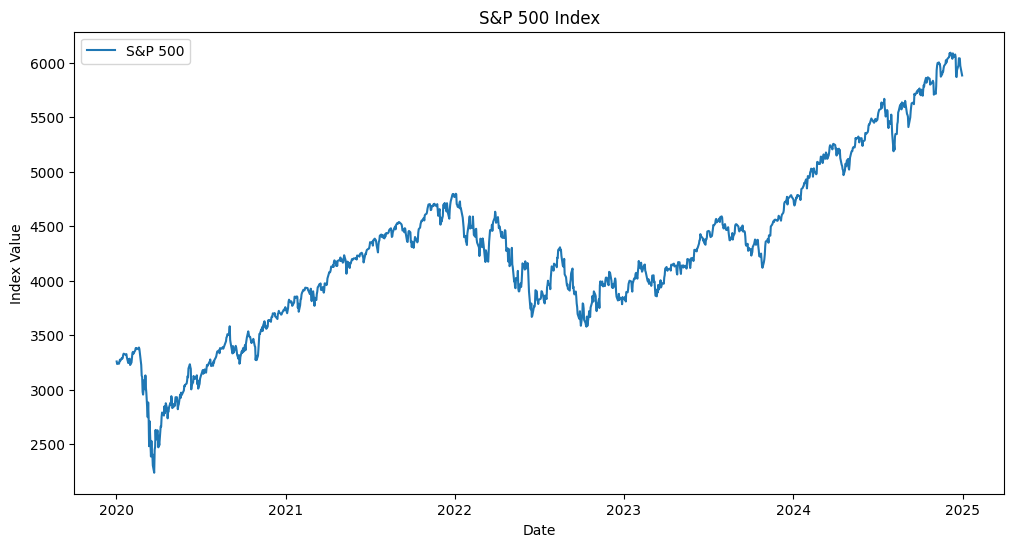

In [44]:
plt.figure(figsize=(12,6))

plt.plot(benchmark_data, label='S&P 500')

plt.title('S&P 500 Index')

plt.xlabel('Date')

plt.ylabel('Index Value')

plt.legend()

plt.show()

**Remark:** This graph also demonstrates an overall upward trend accompanied by significant fluctuations. More precisely, a notable decline can be observed during early 2020, mainly due to COVID-19 and the resulting economic uncertainty. Nevertheless, this period was followed by a strong market recovery in the following years.

Since the assets are on different price scales, we normalize all price series dividing each one by its very first value. This makes the data more suitable for comparison.

In [45]:
normalized_data = data / data.iloc[0]

normalized_benchmark = benchmark_data / benchmark_data.iloc[0]

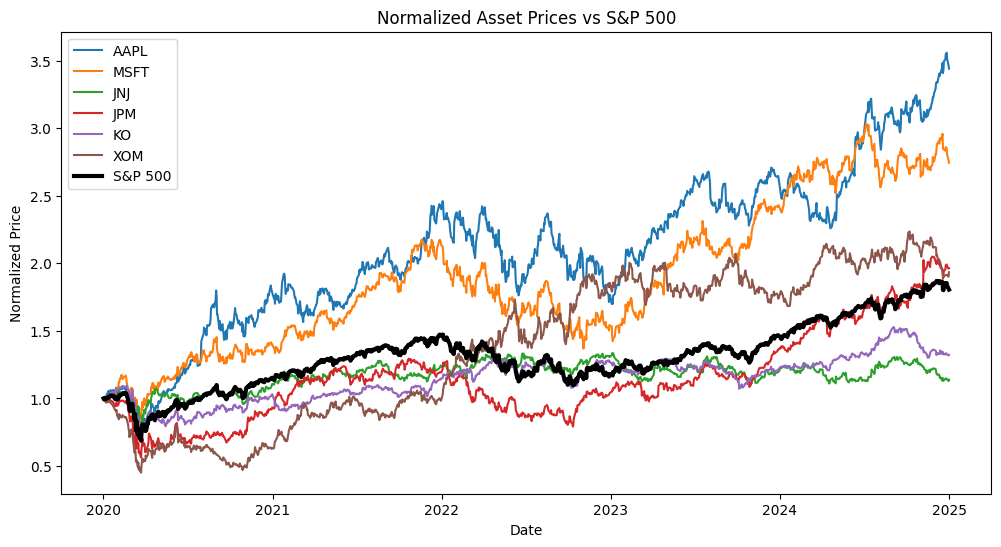

In [46]:
plt.figure(figsize=(12,6))

for stock in stocks:
    
    plt.plot(normalized_data[stock], label=stock)

plt.plot(normalized_benchmark, label='S&P 500', linewidth=3, color='black')

plt.title('Normalized Asset Prices vs S&P 500')

plt.xlabel('Date')

plt.ylabel('Normalized Price')

plt.legend()

plt.show()

**Remark:** Comparing the line plots, one can identify the assets which outperformed or underperformed relative to the S&P 500.

## 6. Log Returns Analysis

We now compute the logarithmic returns of the portfolio assets and the benchmark.

In [47]:
log_returns = np.log(data / data.shift(1))

log_returns.head()

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009770,-0.011645,-0.013284,-0.005471,-0.012530,-0.008072
2020-01-06,0.007937,-0.001248,-0.000795,-0.000366,0.002582,0.007649
2020-01-07,-0.004714,0.006088,-0.017147,-0.007712,-0.009159,-0.008218
2020-01-08,0.015958,-0.000138,0.007771,0.001842,0.015803,-0.015195


In [48]:
benchmark_log_returns = np.log(benchmark_data / benchmark_data.shift(1))

benchmark_log_returns.head()

Ticker,^GSPC
Date,
2020-01-02,NaN
2020-01-03,-0.007085
2020-01-06,0.003527
2020-01-07,-0.002807
2020-01-08,0.004890


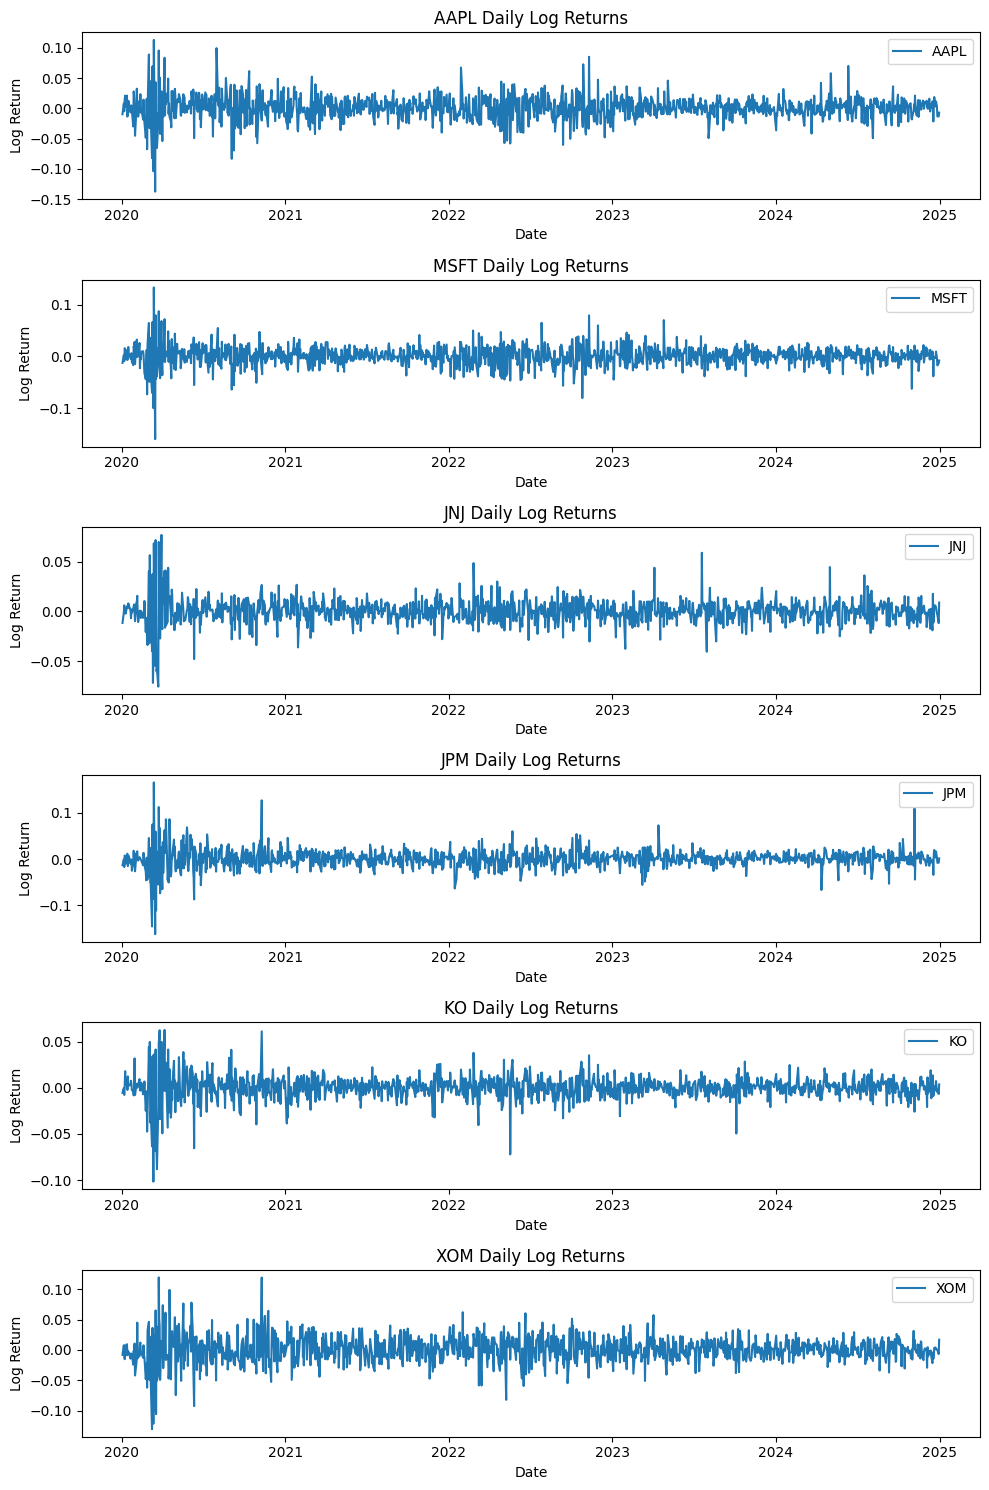

In [49]:
plt.figure(figsize=(10,15))

for stock in stocks:
    
    plt.subplot(len(stocks), 1, stocks.index(stock)+1)
    
    plt.plot(log_returns[stock], label=stock)
    
    plt.title(str(stock) + ' Daily Log Returns')
    
    plt.xlabel('Date')
    
    plt.ylabel('Log Return')
    
    plt.legend()

plt.tight_layout()

plt.show()

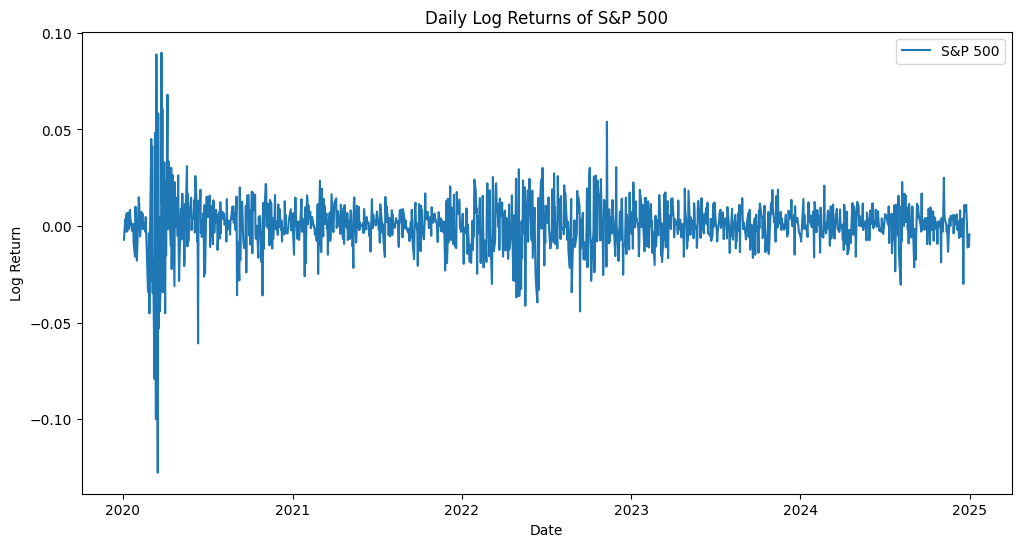

In [50]:
plt.figure(figsize=(12,6))

plt.plot(benchmark_log_returns, label='S&P 500')

plt.title('Daily Log Returns of S&P 500')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.show()

**Remark:** Both the portfolio asset returns and S&P 500 log returns fluctuate around zero and exhibit periods of increased volatility, especially during market stress periods.

Below, we calculate and visualize the annualized mean returns and volatility (always using log returns).

Before proceeding though, note that for an asset $X$ with log returns $X_1, X_2, \dots, X_n$, the (daily) mean and standard deviation are given by the following formulas, respectively:
$$\bar{X} = \frac{1}{n}\sum\limits_{i=1}^{n}X_i$$

$$\sigma (X) = \sqrt{\frac{1}{n-1}\sum\limits_{i=1}^{n}(X_i - \bar{X})^2}.$$

To annualize, one simply has to multiply $\bar{X}$ by the number of trading days in a year, namely 252, and $\sigma(X)$ by $\sqrt{252}$.

In [51]:
annual_mean_returns = log_returns.mean() * 252

annual_mean_returns

Ticker
AAPL    0.247685
JNJ     0.025945
JPM     0.135232
KO      0.055965
MSFT    0.202335
XOM     0.132194
dtype: float64

In [96]:
for stock in stocks:
    print(f'{stock:<4}| Annualized Mean Return: {round(annual_mean_returns[stock] * 100, 2)}%')

AAPL| Annualized Mean Return: 24.77%
MSFT| Annualized Mean Return: 20.23%
JNJ | Annualized Mean Return: 2.59%
JPM | Annualized Mean Return: 13.52%
KO  | Annualized Mean Return: 5.6%
XOM | Annualized Mean Return: 13.22%


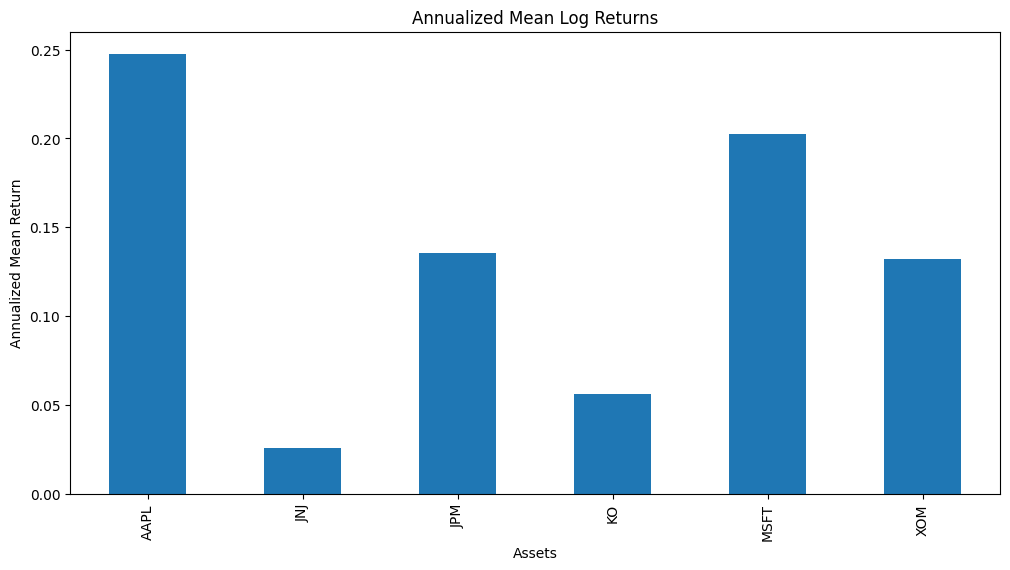

In [52]:
plt.figure(figsize=(12,6))

annual_mean_returns.plot(kind='bar')

plt.title('Annualized Mean Log Returns')

plt.xlabel('Assets')

plt.ylabel('Annualized Mean Return')

plt.show()


In [100]:
annual_volatility = log_returns.std() * np.sqrt(252)

annual_volatility

Ticker
AAPL    0.316540
JNJ     0.196151
JPM     0.324487
KO      0.209010
MSFT    0.305233
XOM     0.343887
dtype: float64

In [99]:
for stock in stocks:
    print(f'{stock:<4}| Annualized Volatility: {round(annual_volatility[stock] * 100, 2)}%')

AAPL| Annualized Volatility: 31.65%
MSFT| Annualized Volatility: 30.52%
JNJ | Annualized Volatility: 19.62%
JPM | Annualized Volatility: 32.45%
KO  | Annualized Volatility: 20.9%
XOM | Annualized Volatility: 34.39%


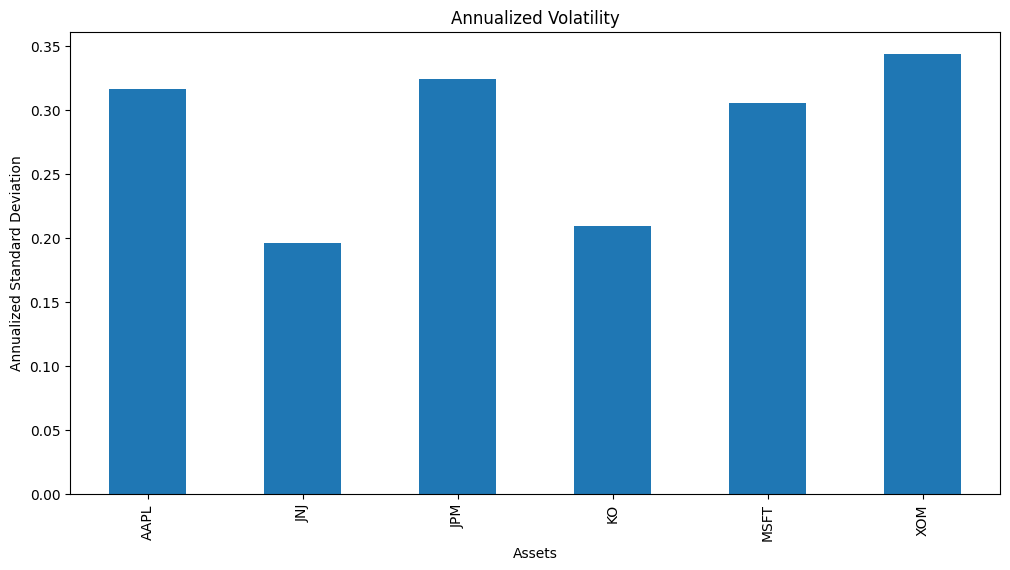

In [54]:
plt.figure(figsize=(12,6))

annual_volatility.plot(kind='bar')

plt.title('Annualized Volatility')

plt.xlabel('Assets')

plt.ylabel('Annualized Standard Deviation')

plt.show()

## 7. Correlation & Covariance Analysis

It is very important to examine the correlation, if any, between the portfolio assets, since portfolio risk depends not only on the volatility of each asset individually, but also on the way the assets interact with one another

Nevertheless, let us discuss some elementary but useful theory first. Suppose we have two assets $X$ and $Y$, with log returns $X_1, X_2, \dots, X_n$ and $Y_1, Y_2, \dots, Y_n$, and daily log return means $\bar{X}$ and $\bar{Y}$, respectively. We define the covariance ($\operatorname{Cov}$) and correlation coefficient ($\rho$) of these assets as follows:

$$\operatorname{Cov}(X, Y) = \frac{1}{n-1}\sum\limits_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})$$

$$\rho (X, Y) = \frac{\operatorname{Cov}(X, Y)}{\sigma(X) \sigma(Y)}.$$

To gain some intuition, covariance measures the tendency of two assets to move together. More precisely, positive covariance implies that the assets tend to move in the same direction, whereas negative covariance implies the opposite. Zero covariance indicates that the assets are uncorrelated.

In addition, $\rho$ is standardized, lying in $[-1, 1].$  Positive $\rho$ implies that the assets tend to move together and the closer $\rho$ to $1$, the stronger the relation between them. Similarly, values close to $-1$ indicate a strong negative correlation.

In [55]:
correlation_matrix = log_returns.corr()

correlation_matrix

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Ticker,,,,,,
AAPL,1.000000,0.374920,0.414320,0.444122,0.750913,0.288141
JNJ,0.374920,1.000000,0.410873,0.589864,0.376939,0.301351
JPM,0.414320,0.410873,1.000000,0.532933,0.424329,0.572315
KO,0.444122,0.589864,0.532933,1.000000,0.436775,0.431263
MSFT,0.750913,0.376939,0.424329,0.436775,1.000000,0.248586
XOM,0.288141,0.301351,0.572315,0.431263,0.248586,1.000000


**Remark:** The element $(i, j)$ of the above matrix, equals the correlation coefficient between the assets in positions $i$ and $j$. Obviously, the diagonal elements equal 1.

The correlation matrix can be visualized using the following heatmap.

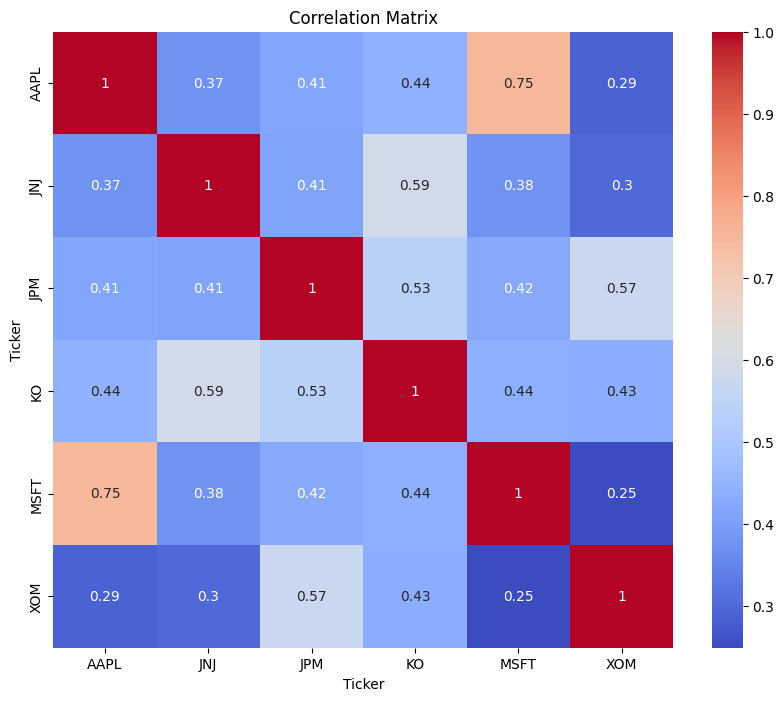

In [56]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

**Remark:** Every pair of assets exhibits positive correlations, implying that the assets tend to move in the same direction under normal market conditions. Nevertheless, the correlations are not perfect, allowing for diversification effects within the portfolio.

We continue with the portfolio covariance matrix.

In [57]:
covariance_matrix = log_returns.cov()

covariance_matrix

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Ticker,,,,,,
AAPL,0.000398,0.000092,0.000169,0.000117,0.000288,0.000124
JNJ,0.000092,0.000153,0.000104,0.000096,0.000090,0.000081
JPM,0.000169,0.000104,0.000418,0.000143,0.000167,0.000253
KO,0.000117,0.000096,0.000143,0.000173,0.000111,0.000123
MSFT,0.000288,0.000090,0.000167,0.000111,0.000370,0.000104
XOM,0.000124,0.000081,0.000253,0.000123,0.000104,0.000469


**Remark:** The element $(i, j)$ of the above matrix, equals the covariance between the assets in positions $i$ and $j$. Obviously, the diagonal elements equal the corresponding variance.

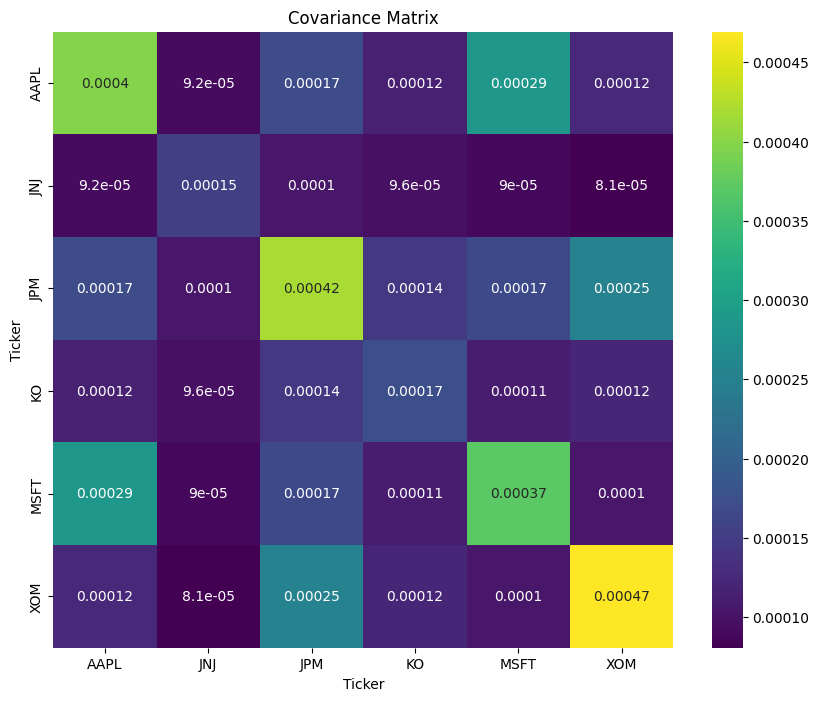

In [58]:
plt.figure(figsize=(10,8))

sns.heatmap(covariance_matrix, annot=True, cmap='viridis')

plt.title('Covariance Matrix')

plt.show()

## 8. Portfolio Return and Volatility

We now study the expected return and volatility of a portfolio consisting of the selected assets.

Suppose the portfolio weights are $w_1, w_2, \dots, w_n,$
where $w_i$ denotes the proportion of capital invested in asset $i.$

Naturally, the weights satisfy
$$\sum\limits_{i=1}^{n}w_i = 1.$$

If $\mu_1, \mu_2, \dots, \mu_n$ denote the annualized mean returns of the assets, then by the linearity of the expected value, the expected portfolio return is defined as follows:
$$\mu_{p} = \sum\limits_{i=1}^{n}w_i\mu _i.$$



Now let's be more precise regarding some elementary probabilistic concepts. 

For two random variables $X_1$, $X_2$ and real numbers $w_1$, $w_2$, it holds

$$\sigma^2(w_1X_1+w_2X_2)=w_1^2\sigma^2(X_1)+w_2^2\sigma^2(X_2)+2w_1w_2\operatorname{Cov}(X_1,X_2).$$

One can easily generalize the above formula for more than two objects:

$$\sigma^2(\sum\limits_{i=1}^{n}w_iX_i) = \sum\limits_{i=1}^{n}\sum\limits_{j=1}^{n}w_iw_j\operatorname{Cov}(X_i, X_j).$$

Thus, the portfolio volatility is given by

$$\sigma_{p} = \sqrt{\sum\limits_{i=1}^{n}\sum\limits_{j=1}^{n}w_iw_j\operatorname{Cov}(X_i, X_j)},$$

which can be written more elegantly as follows:

$$\sigma_{p} = \sqrt{w^T\Sigma w},$$

where $w = (w_1, w_2, \dots, w_n)$ denotes the portfolio weight vector and $w^T$ its transpose, while $\Sigma$ denotes the covariance matrix of asset returns.

Thus, the expression $w^T \Sigma w$ represents a quadratic form describing the total portfolio variance.

As an initial example, we consider a uniformly weighted portfolio.

In [69]:
weights = np.array([1/len(stocks)] * len(stocks))

print(weights)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


Expected annualized portfolio return:

In [71]:
portfolio_expected_return = np.dot(weights, annual_mean_returns)

print(portfolio_expected_return)

0.1332262476769356


Annualized covariance matrix of the portfolio asset returns:

In [72]:
annualized_covariance_matrix = covariance_matrix * 252

annualized_covariance_matrix

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Ticker,,,,,,
AAPL,0.100198,0.023279,0.042556,0.029383,0.072552,0.031365
JNJ,0.023279,0.038475,0.026151,0.024183,0.022568,0.020327
JPM,0.042556,0.026151,0.105292,0.036144,0.042027,0.063863
KO,0.029383,0.024183,0.036144,0.043685,0.027865,0.030997
MSFT,0.072552,0.022568,0.042027,0.027865,0.093167,0.026093
XOM,0.031365,0.020327,0.063863,0.030997,0.026093,0.118258


Annualized portfolio variance:

In [73]:
annualized_portfolio_variance = np.dot(weights.T, np.dot(annualized_covariance_matrix, weights))

print(annualized_portfolio_variance)

0.04271623998164672


Annualized portfolio volatility:

In [76]:
portfolio_volatility = np.sqrt(annualized_portfolio_variance)

print(portfolio_volatility)

0.20667907485192283


In [85]:
print('Expected Annual Portfolio Return:', round(portfolio_expected_return * 100, 2), '%')

print('Annual Portfolio Volatility:', round(portfolio_volatility * 100, 2), '%')

Expected Annual Portfolio Return: 13.32 %
Annual Portfolio Volatility: 20.67 %
